#IT25103066
Gradient Boosting (XGBoost)

Imports

In [19]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Load the preprocessed training dataset

In [20]:
train_df = pd.read_csv("processed_movie_reviews.csv")

train_df.head()

,movie_name,Ratings,word_count,emotion,cleaned_review,tokens_filtered,genre_action,genre_adventure,genre_animation,genre_comedy,...,genre_history,genre_horror,genre_music,genre_mystery,genre_romance,genre_science_fiction,genre_thriller,genre_tv_movie,genre_war,genre_western
0,Waiting to Exhale,3.0,56,anticipation,it had some laughs but overall the motivation ...,laughs overall motivation incomprehensible mad...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,Waiting to Exhale,4.0,373,anticipation,waiting to exhale waiting and waiting and wait...,waiting exhale waiting waiting waiting waiting...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,Waiting to Exhale,4.0,45,anticipation,angela basset was good as expected but whitney...,angela basset good expected whitney range actr...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
3,Waiting to Exhale,5.0,124,anticipation,the movie is okay mediocre might even be the w...,okay mediocre word say tell act angela bassett...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,Waiting to Exhale,5.0,212,anticipation,i got an opportunity to see waiting to exhale ...,got opportunity waiting exhale second recently...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0


Inspect the dataset

In [21]:
print("Shape:", train_df.shape)
print("\nColumns:")
print(train_df.columns.tolist())

print("\nData types:")
print(train_df.dtypes)

print("\nMissing values:")
print(train_df.isnull().sum())

Shape: (16107, 26)

Columns:
['movie_name', 'Ratings', 'word_count', 'emotion', 'cleaned_review', 'tokens_filtered', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_tv_movie', 'genre_war', 'genre_western']

Data types:
movie_name                object
Ratings                  float64
word_count                 int64
emotion                   object
cleaned_review            object
tokens_filtered           object
genre_action               int64
genre_adventure            int64
genre_animation            int64
genre_comedy               int64
genre_crime                int64
genre_documentary          int64
genre_drama                int64
genre_family               int64
genre_fantasy              int64
genre_foreign              int6

Identify the Target Column

In [22]:
print(train_df.columns)

Index(['movie_name', 'Ratings', 'word_count', 'emotion', 'cleaned_review',
       'tokens_filtered', 'genre_action', 'genre_adventure', 'genre_animation',
       'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama',
       'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history',
       'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance',
       'genre_science_fiction', 'genre_thriller', 'genre_tv_movie',
       'genre_war', 'genre_western'],
      dtype='object')


Set Target Column

In [24]:
# Target column
target_column = "Ratings"

# Select numerical features
feature_columns = [
    "word_count",
    "genre_action",
    "genre_adventure",
    "genre_animation",
    "genre_comedy",
    "genre_crime",
    "genre_documentary",
    "genre_drama",
    "genre_family",
    "genre_fantasy",
    "genre_foreign",
    "genre_history",
    "genre_horror",
    "genre_music",
    "genre_mystery",
    "genre_romance",
    "genre_science_fiction",
    "genre_thriller",
    "genre_tv_movie",
    "genre_war",
    "genre_western"
]

X = train_df[feature_columns]
y = train_df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (16107, 21)
y shape: (16107,)

Features:
['word_count', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_tv_movie', 'genre_war', 'genre_western']


Split into training and validation data

In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)

Training data: (12885, 21)
Validation data: (3222, 21)


Create the XGBoost model

In [26]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


Train the XGBoost model

In [28]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model training completed.")

XGBoost model training completed.


Make predictions

In [29]:
y_pred = xgb_model.predict(X_val)

print("Predictions generated successfully.")
print(y_pred[:10])

Predictions generated successfully.
[6.0607967 6.0201554 4.7070875 5.921809  6.0768023 4.833656  6.277806
 6.0697203 6.9097967 6.7303166]


Evaluate the model

In [30]:
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("XGBoost Model Performance")
print("-------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

XGBoost Model Performance
-------------------------
MAE  : 2.3601358181419467
MSE  : 7.739830633527738
RMSE : 2.7820551097215414
R²   : -0.004488038668542194


Compare actual vs predicted values

In [31]:
results = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": y_pred
})

results.head(20)

,Actual,Predicted
0,10.0,6.060797
1,5.0,6.020155
2,10.0,4.707088
3,10.0,5.921809
4,2.0,6.076802
5,1.0,4.833656
6,8.0,6.277806
7,3.0,6.069720
8,10.0,6.909797
9,6.0,6.730317


Feature importance

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,word_count,0.059742
12,genre_horror,0.058083
13,genre_music,0.056346
16,genre_science_fiction,0.053170
18,genre_tv_movie,0.053159
9,genre_fantasy,0.050906
17,genre_thriller,0.050193
10,genre_foreign,0.050094
8,genre_family,0.049195
3,genre_animation,0.049125


Plot feature importance

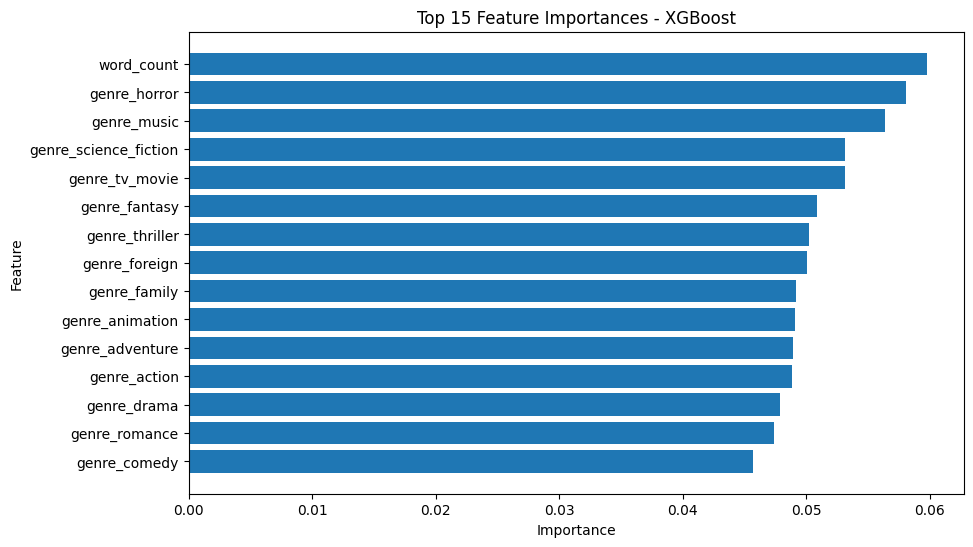

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(15)[::-1],
    feature_importance["Importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost")
plt.show()

Save the trained model

In [35]:
import joblib

joblib.dump(xgb_model, "xgboost_movie_model.pkl")

print("Model saved as xgboost_movie_model.pkl")

Model saved as xgboost_movie_model.pkl
